In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
import transformers
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim

In [3]:
class studentLM(nn.Module):
  def __init__(self, vocab_size, d_model, n_layers, n_head, max_seq_length):
    super().__init__()

    self.embedding_table = nn.Embedding(vocab_size, d_model)

    self.pos_emb = nn.Embedding(max_seq_length, d_model)

    encode_layer = nn.TransformerEncoderLayer(d_model, n_head, 4*d_model)
    self.blocks = nn.TransformerEncoder(encode_layer, n_layers)
    self.lm_head = nn.Linear(d_model, vocab_size)
    self.lm_head.weight = self.embedding_table.weight

  def forward(self,x):
    batch, seq_len = x.shape
    positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)
    emb = self.embedding_table(x)
    pos_emb = self.pos_emb(positions)
    input = emb + pos_emb
    mask = torch.nn.Transformer.generate_square_subsequent_mask(seq_len, device=x.device)
    out = self.blocks(input, mask = mask, is_causal=True)
    output = self.lm_head(out)
    return output

In [4]:
from datasets import load_dataset

ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

In [5]:
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

In [6]:
def tokenize_func(examples):
    return tokenizer(examples['text'], truncation=False)

tokenized_datasets = ds.map(tokenize_func, batched=True, num_proc=4, remove_columns=["text"])

In [7]:
def build_chunks(split_name, seq_len=256):
    ids = tokenized_datasets[split_name]['input_ids']
    all_ids = []
    for x in ids:
        all_ids.extend(x)
    n_chunks = len(all_ids) // (seq_len + 1)
    all_ids = all_ids[: n_chunks * (seq_len + 1)]
    all_ids = torch.tensor(all_ids, dtype=torch.long)
    chunks = all_ids.reshape(n_chunks, seq_len + 1)
    return chunks[:, :-1], chunks[:, 1:]

In [8]:
train_ds = build_chunks('train')
test_ds = build_chunks('test')
val_ds = build_chunks('validation')

In [9]:
from torch.utils.data import TensorDataset, DataLoader

def make_loader(ds_tuple, batch_size=16, shuffle=False):
    inputs, targets = ds_tuple
    dataset = TensorDataset(inputs, targets)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_ds, batch_size=16, shuffle=True)
val_loader   = make_loader(val_ds, batch_size=16, shuffle=False)
test_loader  = make_loader(test_ds, batch_size=16, shuffle=False)

In [10]:
from transformers import GPT2LMHeadModel
teacher = GPT2LMHeadModel.from_pretrained('gpt2')
teacher.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available: ", device)
teacher.to(device)

Device available:  cuda


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [12]:
def distillation_loss(student_logits, teacher_logits, targets, T, alpha):
    kl_loss = nn.KLDivLoss(reduction ='batchmean')
    student_log_logits = F.log_softmax(student_logits/T, dim=-1).view(-1, student_logits.size(-1))
    teacher_log_logits = F.softmax(teacher_logits/T, dim=-1).view(-1, teacher_logits.size(-1))
    loss = kl_loss(student_log_logits, teacher_log_logits)
    CE_loss = nn.CrossEntropyLoss()
    celoss = CE_loss(student_logits.view(-1, student_logits.size(-1)), targets.view(-1))
    return alpha*(T**2)*loss + (1-alpha)*celoss

In [13]:

def train(student, train_loader, optimizer, device, teacher=None, T=1, alpha=0.5):
  student.train()
  losses = 0
  for inputs, targets in train_loader:
    inputs = inputs.to(device)
    targets = targets.to(device)
    student_logits = student(inputs)
    if teacher is not None:
      with torch.no_grad():
        teacher_logits = teacher(inputs).logits
      loss = distillation_loss(student_logits, teacher_logits, targets, T, alpha)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      losses += loss.item()
    else:
      CE_loss = nn.CrossEntropyLoss()
      loss = CE_loss(student_logits.view(-1, student_logits.size(-1)), targets.view(-1))
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      losses += loss.item()
  return losses / len(train_loader)

In [14]:
def evaluate(student, val_loader, device, teacher=None, T=1, alpha=0.5):
  student.eval()
  losses = 0
  with torch.no_grad():
    for inputs, targets in val_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      student_logits = student(inputs)
      if teacher is not None:
        teacher_logits = teacher(inputs).logits
        loss = distillation_loss(student_logits, teacher_logits, targets, T, alpha)
      else:
        CE_loss = nn.CrossEntropyLoss()
        loss = CE_loss(student_logits.view(-1, student_logits.size(-1)), targets.view(-1))
      losses += loss.item()
  return losses / len(val_loader)

In [15]:
list_T = [1,2,4,8,16]
EPOCHS = 8
all_train_loss = []
all_val_loss = []
for i in list_T:
    T = i
    print(f"T = {T}")
    student = studentLM(vocab_size=50257, d_model=256, n_layers=12, n_head=4, max_seq_length=257)
    student.to(device)
    optimizer = optim.AdamW(student.parameters(), lr=1e-4)
    train_loss_per_epoch =[]
    val_loss_per_epoch =[]
    for epochs in range(EPOCHS):
        train_loss = train(student, train_loader, optimizer, device, teacher=teacher, T=T, alpha=0.5)
        eval_loss = evaluate(student, val_loader, device, teacher=teacher, T=T, alpha=0.5)
        train_loss_per_epoch.append(train_loss)
        val_loss_per_epoch.append(eval_loss)
        print(f"T={T} epoch={epochs+1}/{EPOCHS} train_loss={train_loss:.4f} val_loss={eval_loss:.4f}")

    torch.save(student.state_dict(), f"/kaggle/working/student_T{T}.pt") 

    all_train_loss.append(train_loss_per_epoch)
    all_val_loss.append(val_loss_per_epoch)   

T = 1


/tmp/ipykernel_227/4205261849.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.blocks = nn.TransformerEncoder(encode_layer, n_layers)


T=1 epoch=1/8 train_loss=24.4501 val_loss=15.1963
T=1 epoch=2/8 train_loss=12.3142 val_loss=9.1399
T=1 epoch=3/8 train_loss=8.4472 val_loss=7.0869
T=1 epoch=4/8 train_loss=6.9300 val_loss=6.2399
T=1 epoch=5/8 train_loss=6.2580 val_loss=5.8617
T=1 epoch=6/8 train_loss=5.9135 val_loss=5.6568
T=1 epoch=7/8 train_loss=5.6951 val_loss=5.5062
T=1 epoch=8/8 train_loss=5.5487 val_loss=5.4010
T = 2
T=2 epoch=1/8 train_loss=34.4268 val_loss=18.7789
T=2 epoch=2/8 train_loss=13.7467 val_loss=9.2015
T=2 epoch=3/8 train_loss=8.2862 val_loss=6.8550
T=2 epoch=4/8 train_loss=6.7979 val_loss=6.1929
T=2 epoch=5/8 train_loss=6.2539 val_loss=5.8988
T=2 epoch=6/8 train_loss=6.0167 val_loss=5.7945
T=2 epoch=7/8 train_loss=5.9065 val_loss=5.7544
T=2 epoch=8/8 train_loss=5.8446 val_loss=5.7277
T = 4
T=4 epoch=1/8 train_loss=39.8191 val_loss=19.3738
T=4 epoch=2/8 train_loss=13.0054 val_loss=8.0315
T=4 epoch=3/8 train_loss=7.1013 val_loss=5.8412
T=4 epoch=4/8 train_loss=5.8162 val_loss=5.3776
T=4 epoch=5/8 train

In [16]:
student = studentLM(vocab_size=50257, d_model=256, n_layers=12, n_head=4, max_seq_length=257)
student.to(device)
optimizer = optim.AdamW(student.parameters(), lr=1e-4)
train_loss_per_epoch =[]
val_loss_per_epoch =[]
for epochs in range(EPOCHS):
    train_loss = train(student, train_loader, optimizer, device, teacher=None, T=1, alpha=0.5)
    eval_loss = evaluate(student, val_loader, device, teacher=None, T=1, alpha=0.5)
    train_loss_per_epoch.append(train_loss)
    val_loss_per_epoch.append(eval_loss)
    print(f"T={T} epoch={epochs+1}/{EPOCHS} train_loss={train_loss:.4f} val_loss={eval_loss:.4f}")

torch.save(student.state_dict(), "/kaggle/working/student_scratch.pt") 
scratch_train_loss = train_loss_per_epoch
scratch_val_loss = val_loss_per_epoch

/tmp/ipykernel_227/4205261849.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.blocks = nn.TransformerEncoder(encode_layer, n_layers)


T=16 epoch=1/8 train_loss=26.3043 val_loss=17.4270
T=16 epoch=2/8 train_loss=14.9145 val_loss=11.8927
T=16 epoch=3/8 train_loss=10.9970 val_loss=9.5324
T=16 epoch=4/8 train_loss=9.2407 val_loss=8.5202
T=16 epoch=5/8 train_loss=8.4118 val_loss=7.9795
T=16 epoch=6/8 train_loss=7.9360 val_loss=7.6801
T=16 epoch=7/8 train_loss=7.6322 val_loss=7.4750
T=16 epoch=8/8 train_loss=7.4200 val_loss=7.3305


In [17]:
import math

def evaluate_teacher(teacher, loader, device):
    teacher.eval()
    losses = 0
    CE_loss = nn.CrossEntropyLoss()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = teacher(inputs).logits
            loss = CE_loss(logits.view(-1, logits.size(-1)), targets.view(-1))
            losses += loss.item()
    return losses / len(loader)

teacher_val_loss = evaluate_teacher(teacher, val_loader, device)
teacher_val_ppl = math.exp(teacher_val_loss)
print("Teacher val perplexity:", teacher_val_ppl)

Teacher val perplexity: 44.43946098298201


In [18]:
def evaluate_ce_only(student, loader, device):
    student.eval()
    losses = 0
    CE_loss = nn.CrossEntropyLoss()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = student(inputs)
            loss = CE_loss(logits.view(-1, logits.size(-1)), targets.view(-1))
            losses += loss.item()
    return losses / len(loader)

sweep_val_ppl = {}
for T in list_T:
    student = studentLM(vocab_size=50257, d_model=256, n_layers=12, n_head=4, max_seq_length=257)
    student.load_state_dict(torch.load(f"/kaggle/working/student_T{T}.pt"))
    student.to(device)
    val_loss = evaluate_ce_only(student, val_loader, device)
    sweep_val_ppl[T] = math.exp(val_loss)

student.load_state_dict(torch.load("/kaggle/working/student_scratch.pt"))
student.to(device)
scratch_val_ppl = math.exp(evaluate_ce_only(student, val_loader, device))

print(sweep_val_ppl)
print("Scratch perplexity:", scratch_val_ppl)
print("Teacher perplexity:", teacher_val_ppl)

/tmp/ipykernel_227/4205261849.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.blocks = nn.TransformerEncoder(encode_layer, n_layers)


{1: 1207.86053231336, 2: 1242.324885815321, 4: 1248.2629083285794, 8: 1220.9006029799195, 16: 1196.443580873056}
Scratch perplexity: 1526.0819168896437
Teacher perplexity: 44.43946098298201


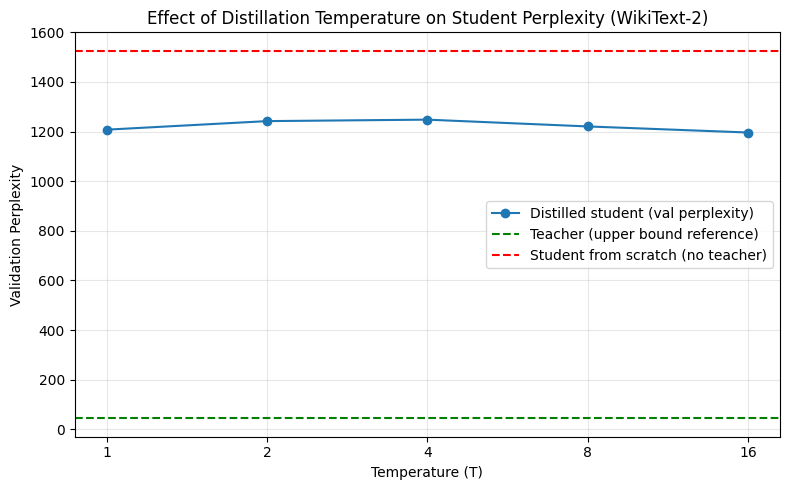

In [19]:
import matplotlib.pyplot as plt

Ts = list(sweep_val_ppl.keys())
ppls = list(sweep_val_ppl.values())

plt.figure(figsize=(8, 5))
plt.plot(Ts, ppls, marker='o', label='Distilled student (val perplexity)')

plt.axhline(y=teacher_val_ppl, color='green', linestyle='--', label='Teacher (upper bound reference)')
plt.axhline(y=scratch_val_ppl, color='red', linestyle='--', label='Student from scratch (no teacher)')

plt.xscale('log', base=2)   # since T is doubling (1,2,4,8,16), log-2 x-axis spaces points evenly
plt.xticks(Ts, [str(t) for t in Ts])   # show actual T values as tick labels, not log-scale numbers

plt.xlabel('Temperature (T)')
plt.ylabel('Validation Perplexity')
plt.title('Effect of Distillation Temperature on Student Perplexity (WikiText-2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/temperature_sweep.png', dpi=150)
plt.show()

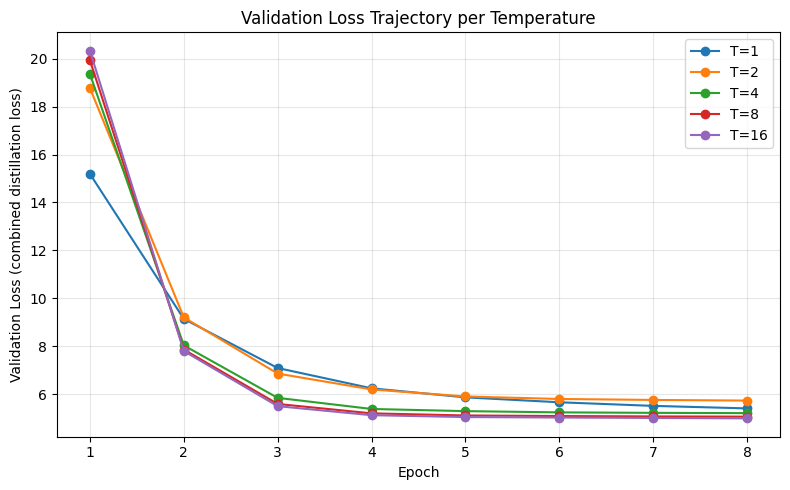

In [20]:
plt.figure(figsize=(8, 5))
for idx, T in enumerate(list_T):
    plt.plot(range(1, EPOCHS+1), all_val_loss[idx], marker='o', label=f'T={T}')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss (combined distillation loss)')
plt.title('Validation Loss Trajectory per Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()